# Response trajectories by initial opinion

This notebook reproduces the response-fraction trajectories for `p_anti = 0.5`, with rows split by `beta` and columns split by participants' initial opinion. Initial opinion is defined as the response at `round_no = 0`; opinion `-1` is shown in the left column and opinion `+1` in the right column. The two figures cover `framing = 1` and `framing = 2`.

For each network, initial-opinion group, and round, response fractions are calculated first. These fractions are then averaged across networks, with 95% confidence intervals based on the SEM across networks.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

%config InlineBackend.figure_format = 'retina'

DATA_PATH = Path('../Clean_files/07_combined_classified.csv')
RESPONSE_LEVELS = [-1, 0, 1]
BETA_LEVELS = [0.0, 0.5]
INITIAL_OPINION_LEVELS = [-1, 1]
REQUIRED_COLUMNS = [
    'round_no',
    'response',
    'framing',
    'beta',
    'p_anti',
    'nid',
    'antic_nudge',
    'participant_code',
]


p_selected = 99

In [17]:
df = pd.read_csv(DATA_PATH, sep=',', usecols=REQUIRED_COLUMNS)

initial_opinions = (
    df.loc[df['round_no'].eq(0), ['participant_code', 'response']]
    .rename(columns={'response': 'initial_opinion'})
)
if initial_opinions['participant_code'].duplicated().any():
    raise ValueError('Expected one initial response per participant.')
if initial_opinions['initial_opinion'].isna().any():
    raise ValueError('Every participant must have a non-missing initial opinion.')
unexpected_initial = set(initial_opinions['initial_opinion'].unique()) - set(INITIAL_OPINION_LEVELS)
if unexpected_initial:
    raise ValueError(f'Unexpected initial opinion levels: {sorted(unexpected_initial)}')

df = df.merge(initial_opinions, on='participant_code', how='left', validate='many_to_one')
plot_data = df.loc[
    (df['framing'] == 1)
    & (df['p_anti'] == p_selected)
    & df['beta'].isin(BETA_LEVELS)
    & df['initial_opinion'].isin(INITIAL_OPINION_LEVELS)
    & df['response'].isin(RESPONSE_LEVELS),
    REQUIRED_COLUMNS + ['initial_opinion'],
].copy()

if sorted(plot_data['initial_opinion'].unique()) != INITIAL_OPINION_LEVELS:
    raise ValueError('Expected initial opinion levels -1 and +1 in the filtered data.')

print(f'Rows used: {len(plot_data):,}')
print(f'Rounds: {plot_data.round_no.min()}–{plot_data.round_no.max()}')
display(
    plot_data.groupby(['beta', 'initial_opinion'])['participant_code']
    .nunique()
    .unstack('initial_opinion')
    .reindex(columns=INITIAL_OPINION_LEVELS)
)
display(plot_data.head())


Rows used: 3,528
Rounds: 0–20


initial_opinion,-1,1
beta,,
0.0,40,40
0.5,44,44


,round_no,response,framing,beta,p_anti,nid,antic_nudge,participant_code,initial_opinion
168,0,-1.0,1,0.5,99.0,2.0,0,4m5w8zmu,-1.0
169,1,-1.0,1,0.5,99.0,2.0,0,4m5w8zmu,-1.0
170,2,-1.0,1,0.5,99.0,2.0,0,4m5w8zmu,-1.0
171,3,-1.0,1,0.5,99.0,2.0,0,4m5w8zmu,-1.0
172,4,0.0,1,0.5,99.0,2.0,0,4m5w8zmu,-1.0


## Calculate per-network fractions and 95% confidence intervals

In [18]:
group_columns = ['beta', 'initial_opinion', 'nid', 'round_no']
nid_fractions = (
    plot_data.groupby(group_columns)['response']
    .value_counts(normalize=True)
    .unstack('response', fill_value=0)
    .reindex(columns=RESPONSE_LEVELS, fill_value=0)
    .rename_axis(columns='response')
    .stack(future_stack=True)
    .rename('fraction')
    .reset_index()
)

mean_fractions = (
    nid_fractions.groupby(
        ['beta', 'initial_opinion', 'round_no', 'response'], as_index=False
    ).agg(
        mean_fraction=('fraction', 'mean'),
        sem_fraction=('fraction', 'sem'),
        n_nid=('nid', 'nunique'),
    )
)
mean_fractions['ci95'] = 1.96 * mean_fractions['sem_fraction']
mean_fractions['ci_lower'] = (mean_fractions['mean_fraction'] - mean_fractions['ci95']).clip(lower=0)
mean_fractions['ci_upper'] = (mean_fractions['mean_fraction'] + mean_fractions['ci95']).clip(upper=1)

fraction_sums = mean_fractions.groupby(
    ['beta', 'initial_opinion', 'round_no']
)["mean_fraction"].sum()
assert fraction_sums.sub(1).abs().max() < 1e-12
display(mean_fractions.head(9))


,beta,initial_opinion,round_no,response,mean_fraction,sem_fraction,n_nid,ci95,ci_lower,ci_upper
0,0.0,-1.0,0,-1,1.000,0.000000,10,0.000000,1.000000,1.000000
1,0.0,-1.0,0,0,0.000,0.000000,10,0.000000,0.000000,0.000000
2,0.0,-1.0,0,1,0.000,0.000000,10,0.000000,0.000000,0.000000
3,0.0,-1.0,1,-1,0.925,0.038188,10,0.074849,0.850151,0.999849
4,0.0,-1.0,1,0,0.050,0.033333,10,0.065333,0.000000,0.115333
5,0.0,-1.0,1,1,0.025,0.025000,10,0.049000,0.000000,0.074000
6,0.0,-1.0,2,-1,0.950,0.033333,10,0.065333,0.884667,1.000000
7,0.0,-1.0,2,0,0.025,0.025000,10,0.049000,0.000000,0.074000
8,0.0,-1.0,2,1,0.025,0.025000,10,0.049000,0.000000,0.074000


## Plot the 2 × 2 trajectories

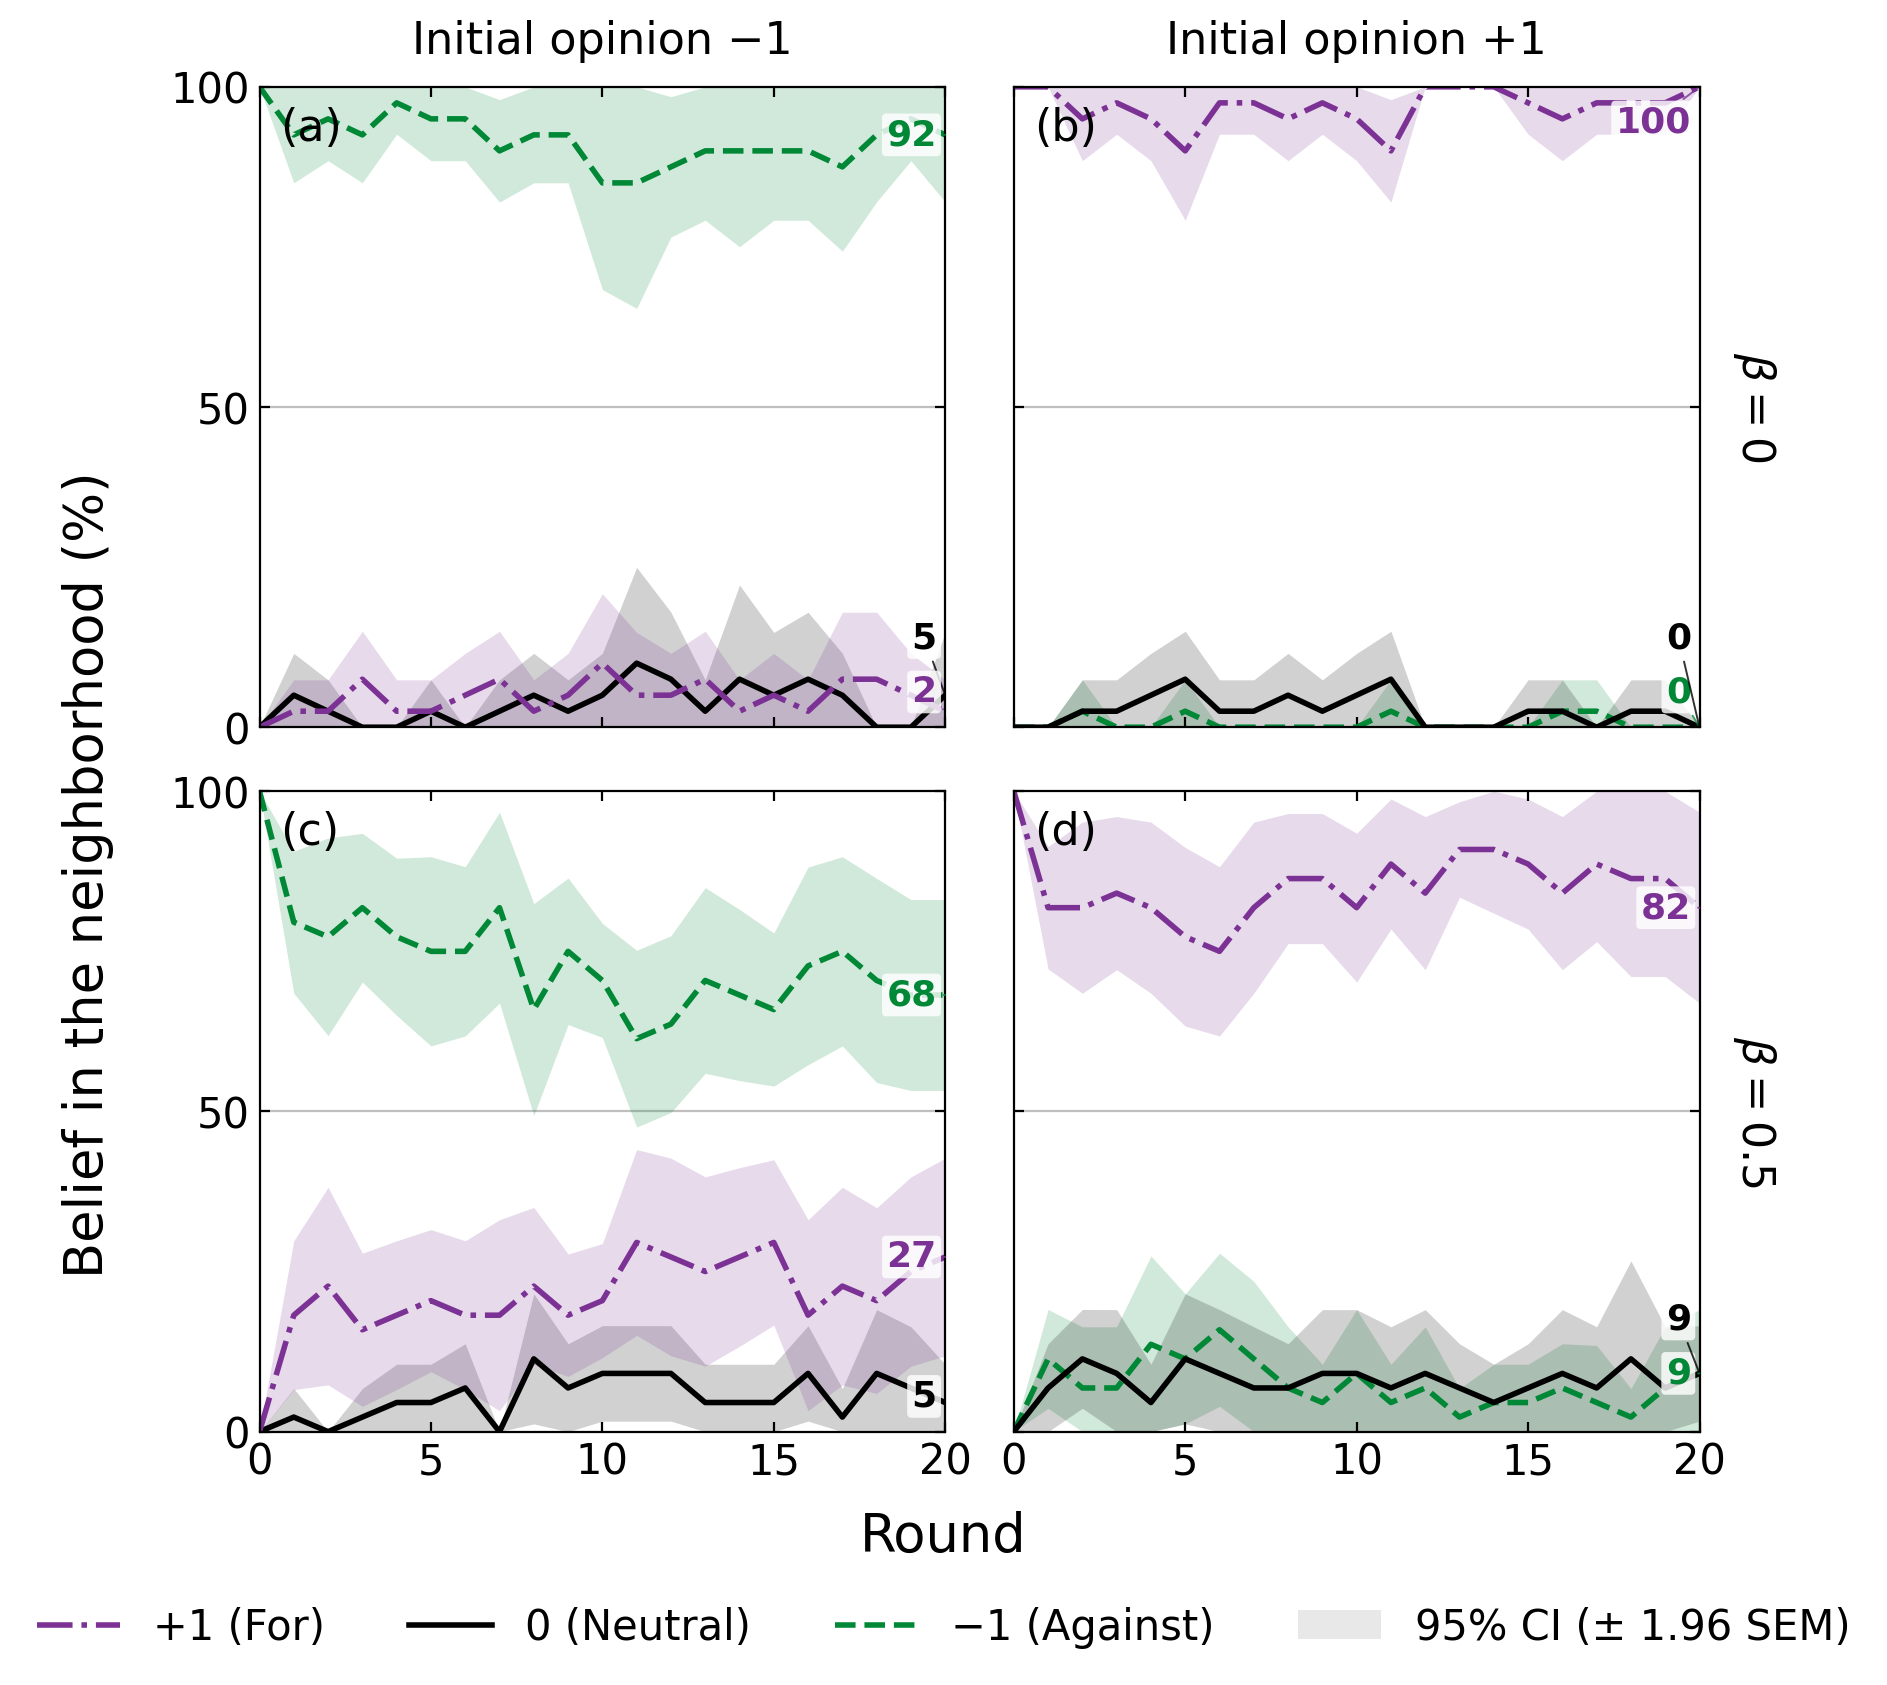

In [19]:
colors = {-1: '#008837', 0: '#000000', 1: '#7b3294'} # colors from colorbrewer2.org
labels = {-1: '−1 (Against)', 0: '0 (Neutral)', 1: '+1 (For)'}
initial_opinion_labels = {-1: 'Initial opinion −1', 1: 'Initial opinion +1'}
annotation_rounds = [20]
line_styles = {-1: '--', 0: '-', 1: '-.'}

def spread_annotation_positions(values, min_gap=0.085, lower=0.055, upper=0.945):
    ordered = sorted(values, key=values.get)
    positions = {response: max(lower, min(upper, values[response])) for response in ordered}
    for previous, current in zip(ordered, ordered[1:]):
        positions[current] = max(positions[current], positions[previous] + min_gap)
    overflow = positions[ordered[-1]] - upper
    if overflow > 0:
        positions = {response: position - overflow for response, position in positions.items()}
    underflow = lower - positions[ordered[0]]
    if underflow > 0:
        positions = {response: position + underflow for response, position in positions.items()}
    return positions

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 19,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})
fig, axes = plt.subplots(2, 2, figsize=(9, 8.2), sharex=True, sharey=True)

for row, beta in enumerate(BETA_LEVELS):
    for col, initial_opinion in enumerate(INITIAL_OPINION_LEVELS):
        ax = axes[row, col]
        panel = mean_fractions.loc[
            (mean_fractions['beta'] == beta)
            & (mean_fractions['initial_opinion'] == initial_opinion)
        ]

        trajectories = {}
        for response in RESPONSE_LEVELS:
            trajectory = panel.loc[panel['response'] == response].sort_values('round_no')
            trajectories[response] = trajectory
            ax.fill_between(
                trajectory['round_no'], trajectory['ci_lower'], trajectory['ci_upper'],
                color=colors[response], alpha=0.18, linewidth=0,
            )
            ax.plot(
                trajectory['round_no'], trajectory['mean_fraction'],
                color=colors[response], linewidth=2,
                linestyle=line_styles[response],
            )

        for annotation_round in annotation_rounds:
            values = {
                response: trajectories[response].loc[
                    trajectories[response]['round_no'] == annotation_round, 'mean_fraction'
                ].iloc[0]
                for response in RESPONSE_LEVELS
            }
            label_positions = spread_annotation_positions(values)
            text_x = annotation_round - 0.25 if annotation_round == 20 else annotation_round
            horizontal_alignment = 'right' if annotation_round == 20 else 'center'
            for response in RESPONSE_LEVELS:
                ax.annotate(
                    f'{values[response] * 100:.0f}',
                    xy=(annotation_round, values[response]),
                    xytext=(text_x, label_positions[response]), textcoords='data',
                    color=colors[response], fontsize=13, fontweight='bold',
                    ha=horizontal_alignment, va='center', clip_on=True, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none', alpha=0.82),
                    arrowprops=dict(arrowstyle='-', color=colors[response], linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1),
                )

        if row == 0:
            ax.set_title(initial_opinion_labels[initial_opinion], fontsize=16, pad=12)
        panel_label = chr(ord('a') + row * len(INITIAL_OPINION_LEVELS) + col)
        ax.text(
            0.03, 0.97, f'({panel_label})',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=16, fontweight='normal',
        )
        ax.set_xlim(plot_data['round_no'].min(), plot_data['round_no'].max())
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1], ['0', '50', '100'])
        ax.set_xticks(range(int(plot_data['round_no'].min()), int(plot_data['round_no'].max()) + 1, 5))
        ax.grid(False)
        ax.axhline(0.5, color='0.75', linewidth=0.8, linestyle='-', zorder=0)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
        if col == len(INITIAL_OPINION_LEVELS) - 1:
            ax.text(
                1.08, 0.5, rf'$\beta = {beta:g}$', transform=ax.transAxes,
                rotation=270, va='center', ha='center', fontsize=16,
            )

legend_order = [1, 0, -1]
legend_handles = [
    Line2D(
        [0], [0], color=colors[response], linewidth=2,
        linestyle=line_styles[response], label=labels[response],
    )
    for response in legend_order
]
legend_handles.append(Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='95% CI (± 1.96 SEM)'))
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.005))
fig.supxlabel('Round', fontsize=19, y=0.08)
fig.supylabel('Belief in the neighborhood (%)', fontsize=19, x=0.01)
fig.subplots_adjust(left=0.12, right=0.92, bottom=0.16, top=0.98, wspace=0.10, hspace=0.10)
fig.savefig(f'Figure_7a_p_{p_selected:.1f}.png', dpi=300, bbox_inches='tight')
plt.show()


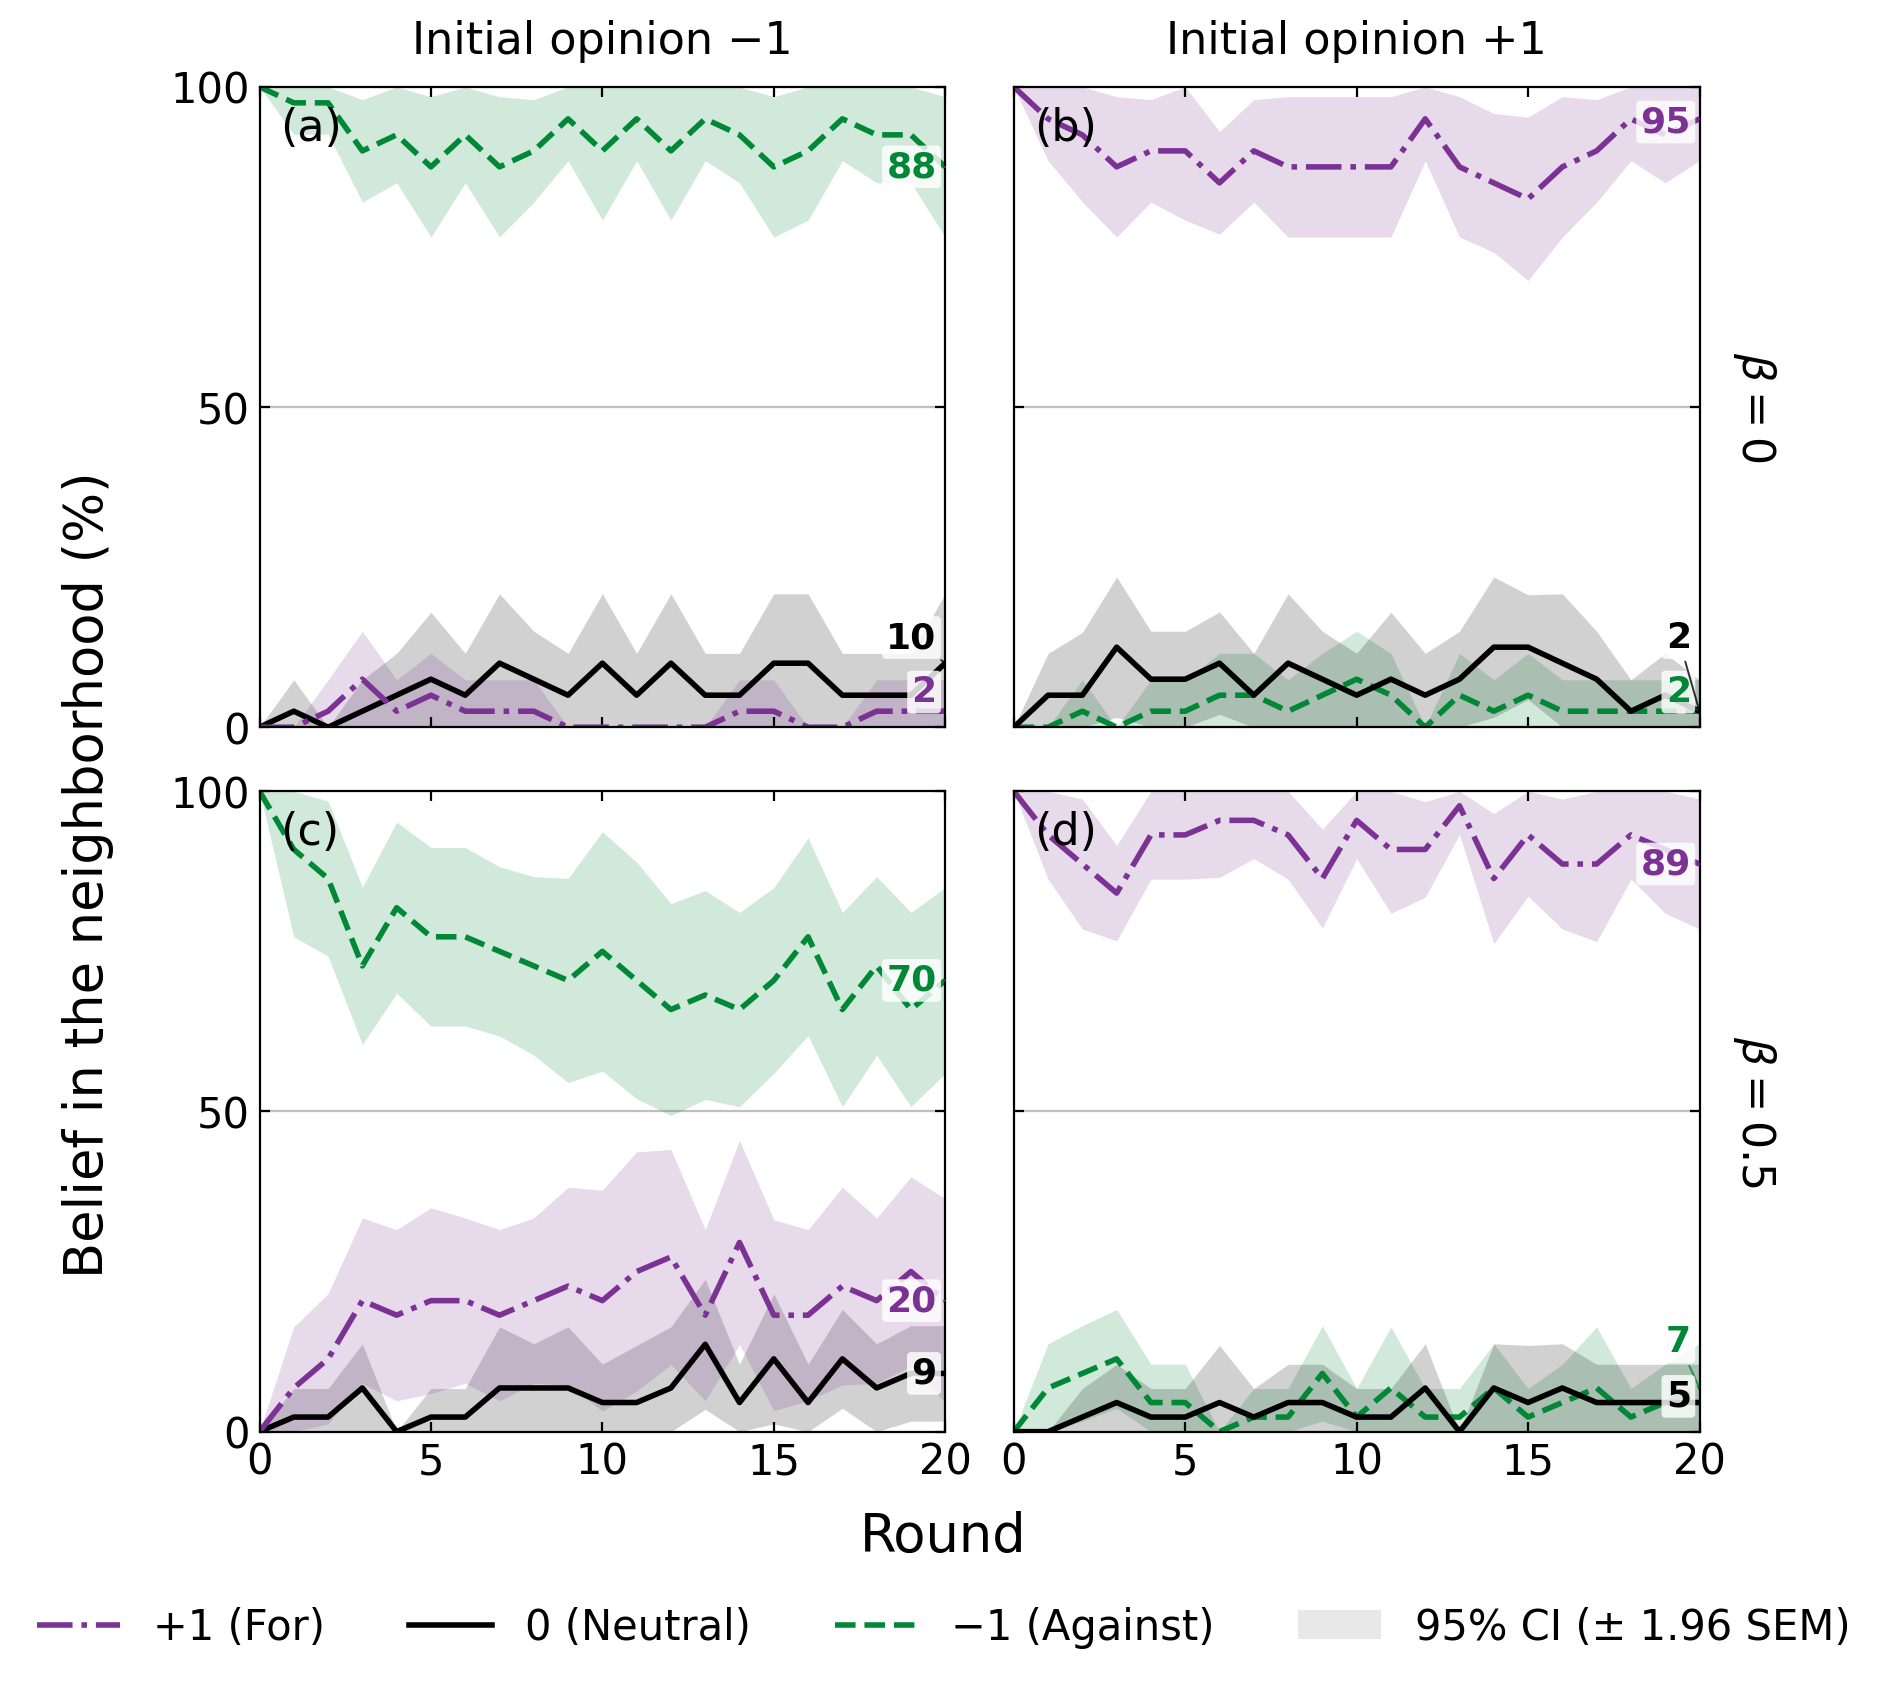

In [20]:
# Repeat the same analysis and figure for framing = 2
plot_data_framing_2 = df.loc[
    (df['framing'] == 2)
    & (df['p_anti'] == p_selected)
    & df['beta'].isin(BETA_LEVELS)
    & df['initial_opinion'].isin(INITIAL_OPINION_LEVELS)
    & df['response'].isin(RESPONSE_LEVELS),
    REQUIRED_COLUMNS + ['initial_opinion'],
].copy()

nid_fractions_framing_2 = (
    plot_data_framing_2.groupby(group_columns)['response']
    .value_counts(normalize=True)
    .unstack('response', fill_value=0)
    .reindex(columns=RESPONSE_LEVELS, fill_value=0)
    .rename_axis(columns='response')
    .stack(future_stack=True)
    .rename('fraction')
    .reset_index()
)

mean_fractions_framing_2 = (
    nid_fractions_framing_2.groupby(
        ['beta', 'initial_opinion', 'round_no', 'response'], as_index=False
    ).agg(
        mean_fraction=('fraction', 'mean'),
        sem_fraction=('fraction', 'sem'),
        n_nid=('nid', 'nunique'),
    )
)
mean_fractions_framing_2['ci95'] = 1.96 * mean_fractions_framing_2['sem_fraction']
mean_fractions_framing_2['ci_lower'] = (
    mean_fractions_framing_2['mean_fraction'] - mean_fractions_framing_2['ci95']
).clip(lower=0)
mean_fractions_framing_2['ci_upper'] = (
    mean_fractions_framing_2['mean_fraction'] + mean_fractions_framing_2['ci95']
).clip(upper=1)
fraction_sums_framing_2 = mean_fractions_framing_2.groupby(
    ['beta', 'initial_opinion', 'round_no']
)["mean_fraction"].sum()
assert fraction_sums_framing_2.sub(1).abs().max() < 1e-12

fig, axes = plt.subplots(2, 2, figsize=(9, 8.2), sharex=True, sharey=True)
for row, beta in enumerate(BETA_LEVELS):
    for col, initial_opinion in enumerate(INITIAL_OPINION_LEVELS):
        ax = axes[row, col]
        panel = mean_fractions_framing_2.loc[
            (mean_fractions_framing_2['beta'] == beta)
            & (mean_fractions_framing_2['initial_opinion'] == initial_opinion)
        ]
        trajectories = {}
        for response in RESPONSE_LEVELS:
            trajectory = panel.loc[panel['response'] == response].sort_values('round_no')
            trajectories[response] = trajectory
            ax.fill_between(
                trajectory['round_no'], trajectory['ci_lower'], trajectory['ci_upper'],
                color=colors[response], alpha=0.18, linewidth=0,
            )
            ax.plot(
                trajectory['round_no'], trajectory['mean_fraction'],
                color=colors[response], linewidth=2,
                linestyle=line_styles[response],
            )

        for annotation_round in annotation_rounds:
            values = {
                response: trajectories[response].loc[
                    trajectories[response]['round_no'] == annotation_round, 'mean_fraction'
                ].iloc[0]
                for response in RESPONSE_LEVELS
            }
            label_positions = spread_annotation_positions(values)
            text_x = annotation_round - 0.25 if annotation_round == 20 else annotation_round
            horizontal_alignment = 'right' if annotation_round == 20 else 'center'
            for response in RESPONSE_LEVELS:
                ax.annotate(
                    f'{values[response] * 100:.0f}', xy=(annotation_round, values[response]),
                    xytext=(text_x, label_positions[response]), textcoords='data',
                    color=colors[response], fontsize=13, fontweight='bold',
                    ha=horizontal_alignment, va='center', clip_on=True, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='none', alpha=0.82),
                    arrowprops=dict(arrowstyle='-', color=colors[response], linewidth=0.7, alpha=0.8, shrinkA=1, shrinkB=1),
                )

        if row == 0:
            ax.set_title(initial_opinion_labels[initial_opinion], fontsize=16, pad=12)
        panel_label = chr(ord('a') + row * len(INITIAL_OPINION_LEVELS) + col)
        ax.text(
            0.03, 0.97, f'({panel_label})',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=16, fontweight='normal',
        )
        ax.set_xlim(plot_data_framing_2['round_no'].min(), plot_data_framing_2['round_no'].max())
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1], ['0', '50', '100'])
        ax.set_xticks(range(int(plot_data_framing_2['round_no'].min()), int(plot_data_framing_2['round_no'].max()) + 1, 5))
        ax.grid(False)
        ax.axhline(0.5, color='0.75', linewidth=0.8, linestyle='-', zorder=0)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
        if col == len(INITIAL_OPINION_LEVELS) - 1:
            ax.text(1.08, 0.5, rf'$\beta = {beta:g}$', transform=ax.transAxes, rotation=270, va='center', ha='center', fontsize=16)

legend_handles = [
    Line2D(
        [0], [0], color=colors[response], linewidth=2,
        linestyle=line_styles[response], label=labels[response],
    )
    for response in legend_order
]
legend_handles.append(Patch(facecolor='0.5', alpha=0.18, edgecolor='none', label='95% CI (± 1.96 SEM)'))
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.005))
fig.supxlabel('Round', fontsize=19, y=0.08)
fig.supylabel('Belief in the neighborhood (%)', fontsize=19, x=0.01)
fig.subplots_adjust(left=0.12, right=0.92, bottom=0.16, top=0.98, wspace=0.10, hspace=0.10)
fig.savefig(f'Figure_7b_p_{p_selected:.1f}.png', dpi=300, bbox_inches='tight')
plt.show()
